In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns


In [3]:
df = pd.read_csv("CSV/acoes_analise.csv")
corr = pd.read_csv("CSV/correlacao_ativos.csv", index_col=0)
df

,ticker,empresa,setor,mercado,preco_atual,preco_minimo_1a,preco_maximo_1a,retorno_acumulado_pct,retorno_30d_pct,retorno_7d_pct,volatilidade_anual_pct,sharpe_ratio,max_drawdown_pct,beta_vs_sp500,volume_medio_diario,volume_total_1a
0,INTC,Intel,Tecnologia,NYSE/NASDAQ,46.42,18.13,54.32,105.09,5.68,2.03,66.84,1.428,-30.05,1.640,102084260,25725233716
1,AMD,AMD,Tecnologia,NYSE/NASDAQ,203.04,78.21,264.33,104.17,-19.44,2.22,65.06,1.440,-31.88,2.297,47967495,12087808827
2,BBDC4.SA,Bradesco,Financeiro,B3,19.78,10.49,21.74,93.64,-5.10,-6.75,28.54,2.533,-10.08,0.432,33381877,8378851200
3,BPAC11.SA,BTG Pactual,Financeiro,B3,57.27,31.02,62.22,89.05,-4.91,-6.25,31.46,2.249,-10.22,0.479,8561359,2148901200
4,GOOGL,Alphabet,Tecnologia,NYSE/NASDAQ,306.07,144.20,343.45,89.02,-8.45,-0.08,30.63,2.283,-15.16,1.025,37250616,9387155419
5,NVDA,NVIDIA,Tecnologia,NYSE/NASDAQ,183.53,94.29,207.03,81.87,-2.65,0.58,42.10,1.663,-22.49,1.780,202090539,50926815912
6,B3SA3.SA,B3,Financeiro,B3,17.56,9.95,18.49,70.87,11.99,-5.03,35.51,1.734,-17.61,0.643,38566018,9680070700
7,LWSA3.SA,Locaweb,Tecnologia,B3,3.97,2.40,4.72,67.38,-13.09,12.46,47.00,1.364,-27.52,0.470,6257219,1570562200
8,GS,Goldman Sachs,Financeiro,NYSE/NASDAQ,834.19,452.84,970.75,62.79,-9.80,-3.19,31.86,1.727,-21.11,1.398,2301091,579874965
9,ITUB4.SA,Itaú Unibanco,Financeiro,B3,42.96,26.56,49.35,56.66,-2.62,-6.45,22.18,2.203,-13.01,0.358,24499901,6149475233


In [4]:
print("df:", df.shape)
print("corr:", corr.shape)
print(df.columns.tolist())

df: (29, 16)
corr: (29, 29)
['ticker', 'empresa', 'setor', 'mercado', 'preco_atual', 'preco_minimo_1a', 'preco_maximo_1a', 'retorno_acumulado_pct', 'retorno_30d_pct', 'retorno_7d_pct', 'volatilidade_anual_pct', 'sharpe_ratio', 'max_drawdown_pct', 'beta_vs_sp500', 'volume_medio_diario', 'volume_total_1a']


In [5]:
#Verificar nulos
nulos = df.isnull().sum()
nulos
#Temos 0 nulos

ticker                    0
empresa                   0
setor                     0
mercado                   0
preco_atual               0
preco_minimo_1a           0
preco_maximo_1a           0
retorno_acumulado_pct     0
retorno_30d_pct           0
retorno_7d_pct            0
volatilidade_anual_pct    0
sharpe_ratio              0
max_drawdown_pct          0
beta_vs_sp500             0
volume_medio_diario       0
volume_total_1a           0
dtype: int64

# Primeira analise, Setores e mercados


In [6]:
#Ver quantidade de ativos tem em cada mercado e setor
print(
    f"Mercados: {df['mercado'].unique()}\n"
    f"Setores: {df['setor'].unique()}\n"
)
print("=== Distribuições Mercado X Setor ===")
Distribuicao_mercado = df['mercado'].value_counts().reset_index()
Distribuicao_mercado.columns = ['Mercado', 'Quantidade']
Distribuicao_setor = df['setor'].value_counts().reset_index()
Distribuicao_setor.columns = ['Setor', 'Quantidade']
DmXDs = df.groupby(['mercado','setor'])['ticker'].count().reset_index()
DmXDs.columns = ['Mercado', 'Setor', 'Ticker']
display(Distribuicao_mercado)
display(Distribuicao_setor)
display(DmXDs)


Mercados: ['NYSE/NASDAQ' 'B3']
Setores: ['Tecnologia' 'Financeiro']

=== Distribuições Mercado X Setor ===


,Mercado,Quantidade
0,NYSE/NASDAQ,18
1,B3,11


,Setor,Quantidade
0,Tecnologia,15
1,Financeiro,14


,Mercado,Setor,Ticker
0,B3,Financeiro,6
1,B3,Tecnologia,5
2,NYSE/NASDAQ,Financeiro,8
3,NYSE/NASDAQ,Tecnologia,10


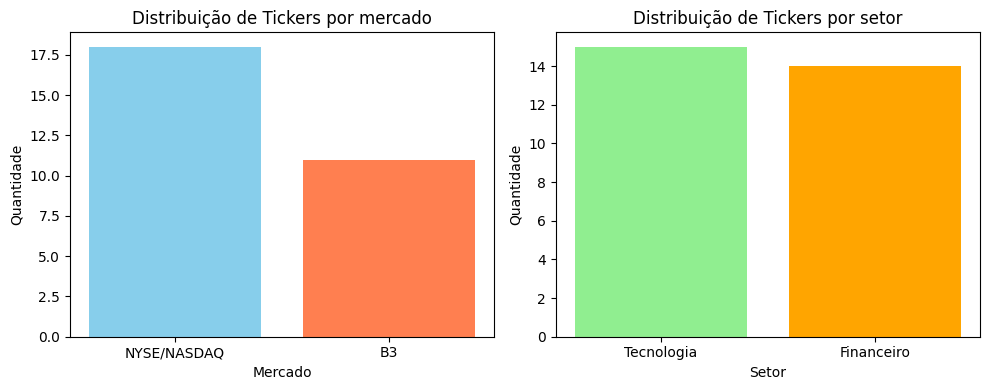

In [7]:
#Analise gráfica
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.bar(Distribuicao_mercado['Mercado'], Distribuicao_mercado['Quantidade'],color=['skyblue', 'coral'])
ax1.set_title('Distribuição de Tickers por mercado')
ax1.set_xlabel('Mercado')
ax1.set_ylabel('Quantidade')


ax2.bar(Distribuicao_setor['Setor'],Distribuicao_setor['Quantidade'], color=['lightgreen','orange'])
ax2.set_title('Distribuição de Tickers por setor')
ax2.set_xlabel('Setor')
ax2.set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig('Distribuicao_tickers.png')

#Segunda analise, Retornos

In [8]:
#Analisar o retorno acumulado
print('=== Qual mercado rendeu mais? ===')
Renda = df.groupby('mercado')['retorno_acumulado_pct'].mean().round(2).reset_index()
Renda.columns = ['Mercado', 'Retorno Acumulado Médio (%)']
display(Renda)

Top_5 = df.groupby(['ticker', 'empresa','mercado'])['retorno_acumulado_pct'].sum().sort_values(ascending=False).reset_index()
Top_5.columns = ['Ticker','Empresa','Mercado',"Retorno Acumulado (%)"]
print('=== Top 5 melhores ativos ===')
display(Top_5.head(5))
print('=== Top 5 piores ativos ===')
display(Top_5.tail(5).reset_index(drop=True))


=== Qual mercado rendeu mais? ===


,Mercado,Retorno Acumulado Médio (%)
0,B3,37.96
1,NYSE/NASDAQ,32.78


=== Top 5 melhores ativos ===


,Ticker,Empresa,Mercado,Retorno Acumulado (%)
0,INTC,Intel,NYSE/NASDAQ,105.09
1,AMD,AMD,NYSE/NASDAQ,104.17
2,BBDC4.SA,Bradesco,B3,93.64
3,BPAC11.SA,BTG Pactual,B3,89.05
4,GOOGL,Alphabet,NYSE/NASDAQ,89.02


=== Top 5 piores ativos ===


,Ticker,Empresa,Mercado,Retorno Acumulado (%)
0,POSI3.SA,Positivo,B3,-5.12
1,V,Visa,NYSE/NASDAQ,-7.57
2,BBAS3.SA,Banco do Brasil,B3,-9.89
3,CASH3.SA,Méliuz,B3,-15.26
4,CRM,Salesforce,NYSE/NASDAQ,-27.01


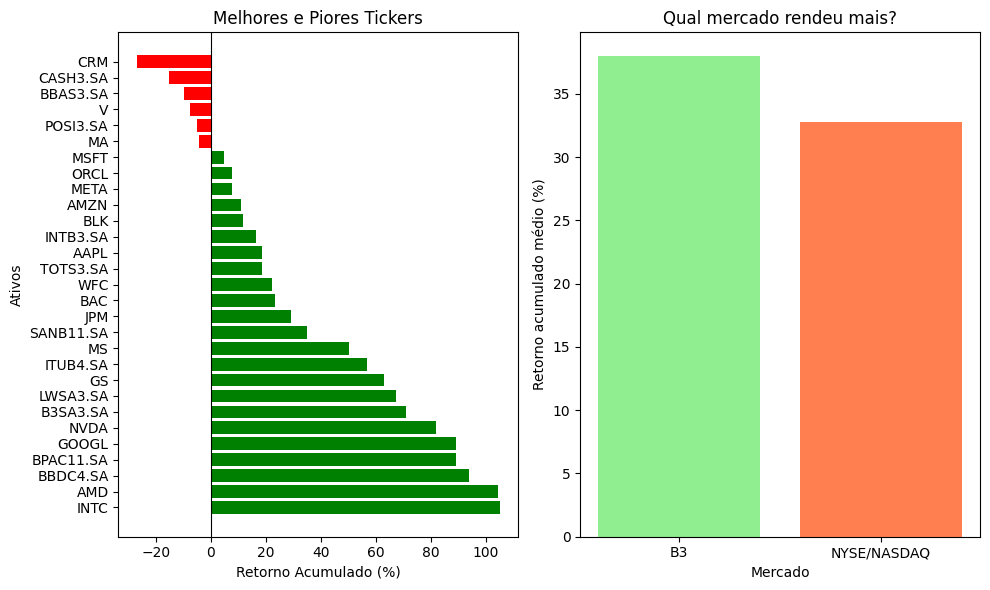

In [9]:
#Analise gráfica
fig , (ax1,ax2) = plt.subplots(1,2, figsize=(10,6))
colors = ['green' if x > 0 else 'red' for x in Top_5['Retorno Acumulado (%)']]

ax1.barh(Top_5['Ticker'], Top_5['Retorno Acumulado (%)'], color=colors)
ax1.set_title('Melhores e Piores Tickers')
ax1.set_ylabel('Ativos')
ax1.set_xlabel('Retorno Acumulado (%)')
ax1.axvline(x=0, color='black', linewidth=0.8)

ax2.bar(Renda['Mercado'],Renda['Retorno Acumulado Médio (%)'], color=['lightgreen','coral'])
ax2.set_title('Qual mercado rendeu mais?')
ax2.set_xlabel('Mercado')
ax2.set_ylabel('Retorno acumulado médio (%)')

plt.tight_layout()
plt.savefig('Retornos.png')


# Terceira analise, Tech BR x Tech USA

In [10]:
techWars = df.groupby(['mercado','setor'])['retorno_acumulado_pct'].mean().round(2).reset_index()
techWars.columns = ['Mercado','Setor','Retorno Acumulado Médio (%)']
display(techWars)

,Mercado,Setor,Retorno Acumulado Médio (%)
0,B3,Financeiro,55.88
1,B3,Tecnologia,16.46
2,NYSE/NASDAQ,Financeiro,23.44
3,NYSE/NASDAQ,Tecnologia,40.25


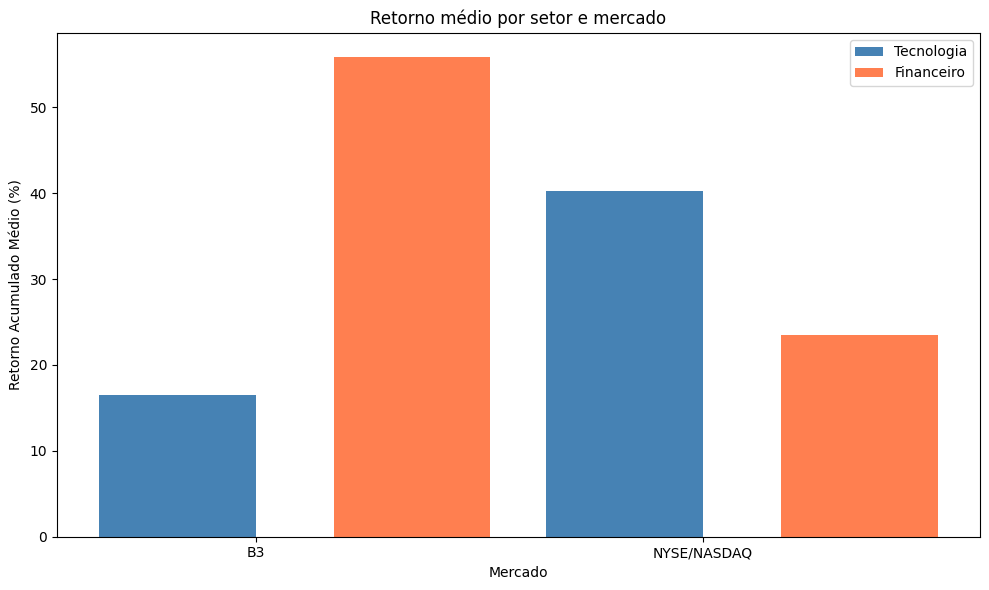

In [11]:
#Analise gráfica
x=np.arange(2)
largura = 0.35

tech = techWars[techWars['Setor'] == 'Tecnologia']['Retorno Acumulado Médio (%)'].values
financa = techWars[techWars['Setor'] == 'Financeiro']['Retorno Acumulado Médio (%)'].values
mercados = ['B3','NYSE/NASDAQ']


fig, ax = plt.subplots(figsize=(10,6))

barra1 = ax.bar(x-largura/2, tech,largura, label='Tecnologia', color='steelblue')
barra2 = ax.bar(x+largura, financa,largura, label="Financeiro",color='coral')

ax.set_xticks(x)
ax.set_xticklabels(mercados)
ax.set_title("Retorno médio por setor e mercado")
ax.set_xlabel('Mercado')
ax.set_ylabel('Retorno Acumulado Médio (%)')
ax.legend()

plt.tight_layout()
plt.savefig('TechBRXTechUSA.png')


## Volatilidade e Risco

In [12]:
#Qual mercado oscila mais

mercado_volatil = df.groupby('mercado')['volatilidade_anual_pct'].mean().round(2)

vol_b3 = mercado_volatil['B3']
vol_eua = mercado_volatil['NYSE/NASDAQ']

volatil_display = mercado_volatil.reset_index()
volatil_display.columns = ['Mercado', 'Volatilidade anual (%)']
display(volatil_display)
print('='*100)
for nome, valor in (['B3', vol_b3], ['NYSE/NASDAQ', vol_eua]):
  if valor <= 15.0:
    print(f'{nome} com Baixa volatilidade')
  elif valor >= 15.0 and valor <= 30.0:
    print(f'{nome} com volatilidade moderada')
  elif valor >= 30.0 and valor <= 50.0:
    print(f'Volatilidade da {nome} está alta')
  else:
    print(f'Volatilidade da {nome} está muito alta!')


,Mercado,Volatilidade anual (%)
0,B3,36.38
1,NYSE/NASDAQ,36.33


Volatilidade da B3 está alta
Volatilidade da NYSE/NASDAQ está alta


In [36]:

#Qual setor volatilidade de setor por mercado
setor_volatil = df.groupby(['mercado','setor'])['volatilidade_anual_pct'].mean().round(2).reset_index()
setor_volatil.columns = ['Mercado','Setor','Volatilidade Anual (%)']
display(setor_volatil)
rank_vl_est = df[['ticker','empresa','setor','mercado','volatilidade_anual_pct']].sort_values('volatilidade_anual_pct',ascending=False).reset_index(drop=True)
display(rank_vl_est)


,Mercado,Setor,Volatilidade Anual (%)
0,B3,Financeiro,29.15
1,B3,Tecnologia,45.06
2,NYSE/NASDAQ,Financeiro,27.55
3,NYSE/NASDAQ,Tecnologia,43.35


,ticker,empresa,setor,mercado,volatilidade_anual_pct
0,CASH3.SA,Méliuz,Tecnologia,B3,75.17
1,INTC,Intel,Tecnologia,NYSE/NASDAQ,66.84
2,AMD,AMD,Tecnologia,NYSE/NASDAQ,65.06
3,ORCL,Oracle,Tecnologia,NYSE/NASDAQ,61.24
4,LWSA3.SA,Locaweb,Tecnologia,B3,47.00
5,NVDA,NVIDIA,Tecnologia,NYSE/NASDAQ,42.10
6,META,Meta,Tecnologia,NYSE/NASDAQ,39.20
7,POSI3.SA,Positivo,Tecnologia,B3,39.18
8,B3SA3.SA,B3,Financeiro,B3,35.51
9,INTB3.SA,Intelbras,Tecnologia,B3,35.31


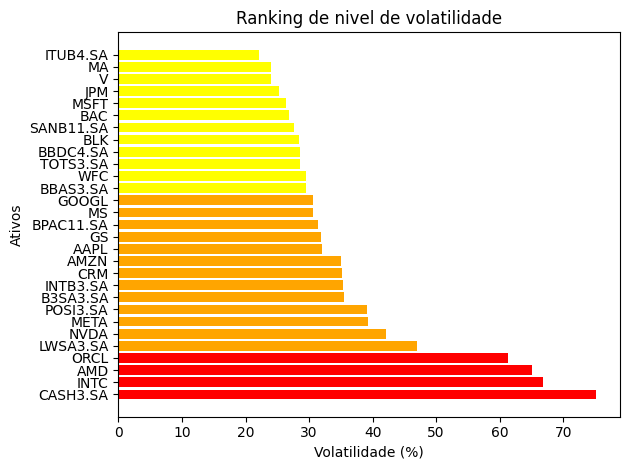

In [14]:
#Análise gráfica
colors = ['green' if x <= 15.0 else ('yellow' if x >=15.0 and x <=30.0 else ('orange' if x >=30.0 and x <= 50.0 else 'red')) for x in rank_vl_est['volatilidade_anual_pct']]

plt.barh(rank_vl_est['ticker'],rank_vl_est['volatilidade_anual_pct'], color=colors)
plt.title('Ranking de nivel de volatilidade')
plt.xlabel('Volatilidade (%)')
plt.ylabel('Ativos')

plt.tight_layout()
plt.savefig('Volatilidade.png')

#Quinta analise Sharp ratio

In [15]:

#Verificar a media de sharp dos dois mercados
sharpeMean = df.groupby('mercado')['sharpe_ratio'].mean().round(2)
display(sharpeMean)
#B3 está acima de NYSE com seu ratio de 1.16

#Verificar os 5 ativos mais recompensados
ativosRecompensados = df.groupby(['ticker','empresa','setor','mercado'])['sharpe_ratio'].sum().sort_values(ascending=False).head(5)
display(ativosRecompensados)

#Os piores sharpes
ativosSharpeBaixo = df.groupby(['ticker','empresa','setor','mercado'])['sharpe_ratio'].sum().sort_values(ascending=False).tail(5)
display(ativosSharpeBaixo)

mercado
B3             1.16
NYSE/NASDAQ    0.82
Name: sharpe_ratio, dtype: float64

ticker     empresa        setor       mercado    
BBDC4.SA   Bradesco       Financeiro  B3             2.533
GOOGL      Alphabet       Tecnologia  NYSE/NASDAQ    2.283
BPAC11.SA  BTG Pactual    Financeiro  B3             2.249
ITUB4.SA   Itaú Unibanco  Financeiro  B3             2.203
B3SA3.SA   B3             Financeiro  B3             1.734
Name: sharpe_ratio, dtype: float64

ticker    empresa          setor       mercado    
POSI3.SA  Positivo         Tecnologia  B3             0.058
MA        Mastercard       Financeiro  NYSE/NASDAQ   -0.064
BBAS3.SA  Banco do Brasil  Financeiro  B3            -0.213
V         Visa             Financeiro  NYSE/NASDAQ   -0.216
CRM       Salesforce       Tecnologia  NYSE/NASDAQ   -0.741
Name: sharpe_ratio, dtype: float64

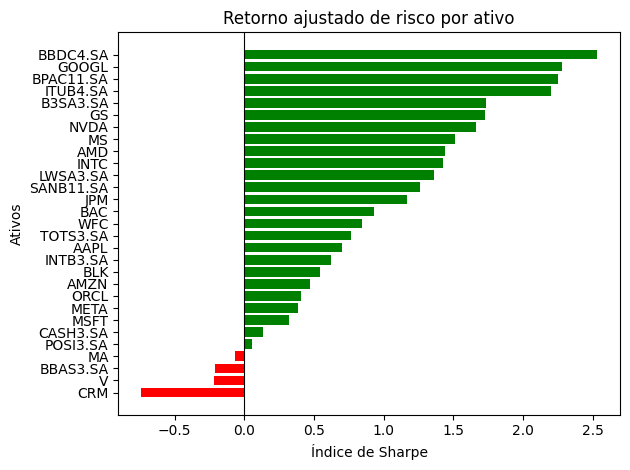

In [16]:
#Cria o rank de todos
sharpe_rank = df[['ticker', 'sharpe_ratio']].sort_values('sharpe_ratio',ascending=True).reset_index()

#Analise gráfica
colors=['green' if x >0 else 'red' for x in sharpe_rank['sharpe_ratio']]

plt.barh(sharpe_rank['ticker'], sharpe_rank['sharpe_ratio'],color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Retorno ajustado de risco por ativo')
plt.xlabel('Índice de Sharpe')
plt.ylabel('Ativos')

plt.tight_layout()
plt.savefig('ativos_por_risco.png')


## Maior queda que um ativo sofreu do seu pico mais alto até o ponto mais baixo 'Drawdown'

In [17]:
#Visualizar os drawdowns
df[['ticker','empresa','mercado','max_drawdown_pct']]

,ticker,empresa,mercado,max_drawdown_pct
0,INTC,Intel,NYSE/NASDAQ,-30.05
1,AMD,AMD,NYSE/NASDAQ,-31.88
2,BBDC4.SA,Bradesco,B3,-10.08
3,BPAC11.SA,BTG Pactual,B3,-10.22
4,GOOGL,Alphabet,NYSE/NASDAQ,-15.16
5,NVDA,NVIDIA,NYSE/NASDAQ,-22.49
6,B3SA3.SA,B3,B3,-17.61
7,LWSA3.SA,Locaweb,B3,-27.52
8,GS,Goldman Sachs,NYSE/NASDAQ,-21.11
9,ITUB4.SA,Itaú Unibanco,B3,-13.01


In [18]:
#Drawdown médio mais severo
drawn_mean = df.groupby('mercado')['max_drawdown_pct'].mean().round(2).reset_index()
drawn_mean.columns = ['Mercado', 'Drawdown Médio (%)']
display(drawn_mean)

,Mercado,Drawdown Médio (%)
0,B3,-26.40
1,NYSE/NASDAQ,-24.81


In [19]:
#Ativos que mais sofreram e o que resistiram a queda
draw_rank = df.groupby(['ticker','empresa','mercado'])['max_drawdown_pct'].sum().sort_values(ascending=False).reset_index()
draw_rank.columns=['Ticker','Empresa','Mercado','Drawdown Máximo (%)']
print("==== Top 5 que mais sofreram ====")
display(draw_rank.tail(5).reset_index(drop=True))
print('==== Top 5 que mais resistiram ====')
display(draw_rank.head(5).reset_index(drop=True))

==== Top 5 que mais sofreram ====


,Ticker,Empresa,Mercado,Drawdown Máximo (%)
0,POSI3.SA,Positivo,B3,-33.12
1,BBAS3.SA,Banco do Brasil,B3,-37.19
2,CRM,Salesforce,NYSE/NASDAQ,-38.51
3,ORCL,Oracle,NYSE/NASDAQ,-58.25
4,CASH3.SA,Méliuz,B3,-68.43


==== Top 5 que mais resistiram ====


,Ticker,Empresa,Mercado,Drawdown Máximo (%)
0,BBDC4.SA,Bradesco,B3,-10.08
1,BPAC11.SA,BTG Pactual,B3,-10.22
2,ITUB4.SA,Itaú Unibanco,B3,-13.01
3,GOOGL,Alphabet,NYSE/NASDAQ,-15.16
4,JPM,JPMorgan,NYSE/NASDAQ,-15.75


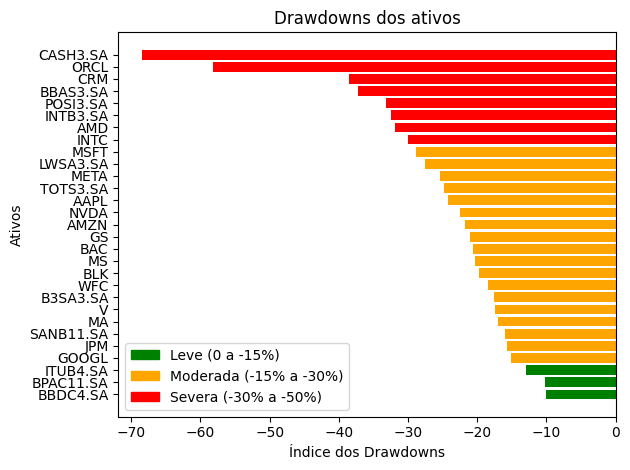

In [20]:
#Análise gráfica
colors=['green' if x >= -15.0 else ('orange' if x >= -30.0 else ('red' if x >= -50.0 else 'red')) for x in draw_rank['Drawdown Máximo (%)']]
legendas = [
    Patch(color='green',label='Leve (0 a -15%)'),
    Patch(color='orange',label='Moderada (-15% a -30%)'),
    Patch(color='red',label='Severa (-30% a -50%)'),
]


plt.barh(draw_rank['Ticker'],draw_rank['Drawdown Máximo (%)'],color=colors)
plt.title('Drawdowns dos ativos')
plt.legend(handles=legendas, loc='lower left')
plt.xlabel('Índice dos Drawdowns')
plt.ylabel('Ativos')
plt.tight_layout()
plt.savefig('drawdown.png')


### Insight da analise:


## Análise da Beta dos ativos

In [21]:
#Visualizar betas
Beta = df[['ticker','setor','empresa','mercado','beta_vs_sp500']]

In [22]:
#Mercado com a maior Beta
beta_mercados = df.groupby('mercado')['beta_vs_sp500'].mean().round(2).reset_index()
beta_mercados.columns = ['Mercado','Beta S&P500 Média']
display(beta_mercados)

,Mercado,Beta S&P500 Média
0,B3,0.46
1,NYSE/NASDAQ,1.28


In [23]:
#Separando em variaveis os mercados
eua=Beta[Beta['mercado'] == 'NYSE/NASDAQ']
br=Beta[Beta['mercado'] == 'B3']
print('=== Ativos mais sensíveis do mercado americano ===')
sensiveis_eua = eua[eua['beta_vs_sp500'] > 1].sort_values('beta_vs_sp500',ascending=False).reset_index(drop=True).round(2)
display(sensiveis_eua)
print('=== Ativos mais defensivos ===')
defensivos_br = br[br['beta_vs_sp500'] < 1].sort_values('beta_vs_sp500',ascending=True).reset_index(drop=True).round(2)
display(defensivos_br)

=== Ativos mais sensíveis do mercado americano ===


,ticker,setor,empresa,mercado,beta_vs_sp500
0,AMD,Tecnologia,AMD,NYSE/NASDAQ,2.30
1,NVDA,Tecnologia,NVIDIA,NYSE/NASDAQ,1.78
2,INTC,Tecnologia,Intel,NYSE/NASDAQ,1.64
3,META,Tecnologia,Meta,NYSE/NASDAQ,1.48
4,ORCL,Tecnologia,Oracle,NYSE/NASDAQ,1.41
5,GS,Financeiro,Goldman Sachs,NYSE/NASDAQ,1.40
6,AMZN,Tecnologia,Amazon,NYSE/NASDAQ,1.37
7,MS,Financeiro,Morgan Stanley,NYSE/NASDAQ,1.37
8,AAPL,Tecnologia,Apple,NYSE/NASDAQ,1.34
9,BLK,Financeiro,BlackRock,NYSE/NASDAQ,1.18


=== Ativos mais defensivos ===


,ticker,setor,empresa,mercado,beta_vs_sp500
0,BBAS3.SA,Financeiro,Banco do Brasil,B3,0.22
1,TOTS3.SA,Tecnologia,TOTVS,B3,0.26
2,ITUB4.SA,Financeiro,Itaú Unibanco,B3,0.36
3,BBDC4.SA,Financeiro,Bradesco,B3,0.43
4,POSI3.SA,Tecnologia,Positivo,B3,0.45
5,SANB11.SA,Financeiro,Santander BR,B3,0.45
6,LWSA3.SA,Tecnologia,Locaweb,B3,0.47
7,BPAC11.SA,Financeiro,BTG Pactual,B3,0.48
8,INTB3.SA,Tecnologia,Intelbras,B3,0.52
9,B3SA3.SA,Financeiro,B3,B3,0.64


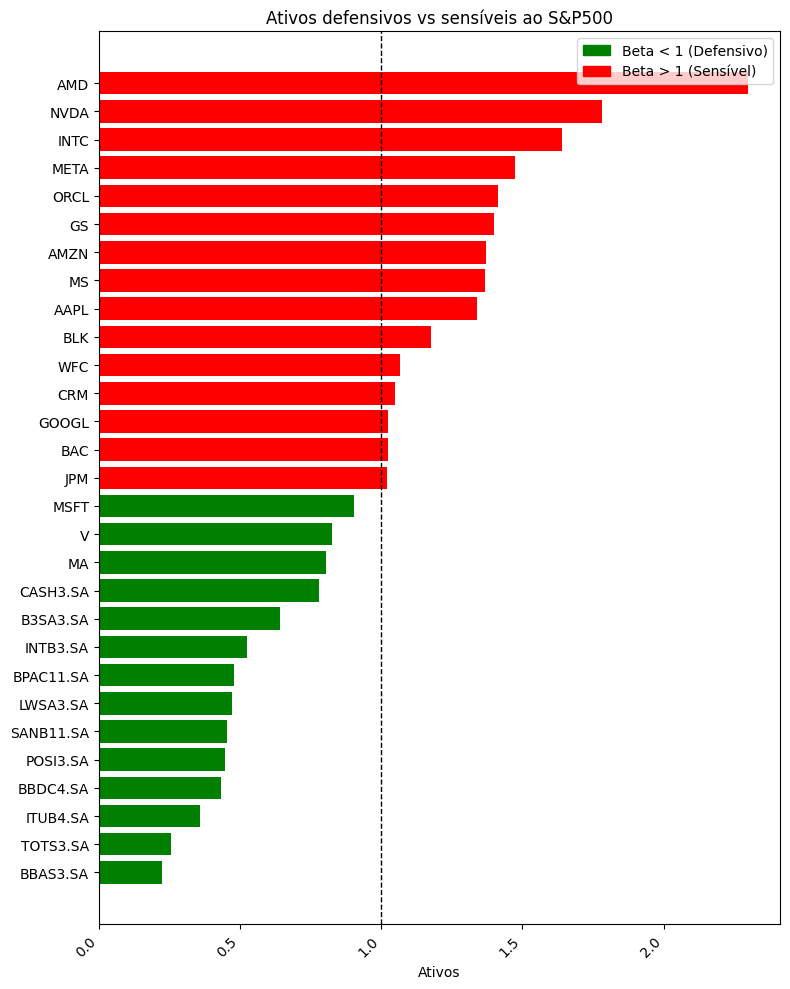

In [24]:
#Analise gráfica
beta_sorted = df[['ticker', 'beta_vs_sp500']].sort_values('beta_vs_sp500',ascending=True).reset_index(drop=True)

colors = ['green' if x < 1.0 else 'red' for x in beta_sorted['beta_vs_sp500']]
legenda = [
    Patch(color = 'green', label='Beta < 1 (Defensivo)'),
    Patch(color = 'red', label='Beta > 1 (Sensível)'),
]
plt.figure(figsize=(8,10))
plt.barh(beta_sorted['ticker'],beta_sorted['beta_vs_sp500'], color=colors)
plt.title('Ativos defensivos vs sensíveis ao S&P500')
plt.legend(handles = legenda, loc='upper right')
plt.xlabel('Ativos')
plt.xticks(rotation=45,ha='right')
plt.axvline(x=1,color='black', linewidth = 1, linestyle = '--',label = 'Beta = 1')

plt.tight_layout()
plt.savefig('beta.png')


## Análise do volume médio diario

In [25]:
volume = df[['ticker','setor','empresa','mercado','volume_medio_diario','volume_total_1a']]
volume

,ticker,setor,empresa,mercado,volume_medio_diario,volume_total_1a
0,INTC,Tecnologia,Intel,NYSE/NASDAQ,102084260,25725233716
1,AMD,Tecnologia,AMD,NYSE/NASDAQ,47967495,12087808827
2,BBDC4.SA,Financeiro,Bradesco,B3,33381877,8378851200
3,BPAC11.SA,Financeiro,BTG Pactual,B3,8561359,2148901200
4,GOOGL,Tecnologia,Alphabet,NYSE/NASDAQ,37250616,9387155419
5,NVDA,Tecnologia,NVIDIA,NYSE/NASDAQ,202090539,50926815912
6,B3SA3.SA,Financeiro,B3,B3,38566018,9680070700
7,LWSA3.SA,Tecnologia,Locaweb,B3,6257219,1570562200
8,GS,Financeiro,Goldman Sachs,NYSE/NASDAQ,2301091,579874965
9,ITUB4.SA,Financeiro,Itaú Unibanco,B3,24499901,6149475233


In [26]:
#Mercado com o maior volume
media_dos_volumes = volume.groupby('mercado')['volume_medio_diario'].mean().reset_index().round(2)
media_dos_volumes.columns = ['Mercado', 'Volume Médio Diario (Milhões)']
display(media_dos_volumes)

,Mercado,Volume Médio Diario (Milhões)
0,B3,14074068.18
1,NYSE/NASDAQ,35800877.00


In [27]:
#Os ativos mais liquidos
maisLiquidos = volume.groupby(['ticker','setor','empresa','mercado'])['volume_medio_diario'].sum().sort_values(ascending=False).reset_index()
maisLiquidos.columns = ['Ticker','Setor','Empresa','Mercado','Volume Médio Diario (Milhões)']
print('=== Mais Liquidos ===')
display(maisLiquidos.head(5))
print('=== Menos negociados ===')
display(maisLiquidos.tail(5))


=== Mais Liquidos ===


,Ticker,Setor,Empresa,Mercado,Volume Médio Diario (Milhões)
0,NVDA,Tecnologia,NVIDIA,NYSE/NASDAQ,202090539
1,INTC,Tecnologia,Intel,NYSE/NASDAQ,102084260
2,AAPL,Tecnologia,Apple,NYSE/NASDAQ,53669658
3,AMD,Tecnologia,AMD,NYSE/NASDAQ,47967495
4,AMZN,Tecnologia,Amazon,NYSE/NASDAQ,47000841


=== Menos negociados ===


,Ticker,Setor,Empresa,Mercado,Volume Médio Diario (Milhões)
24,CASH3.SA,Tecnologia,Méliuz,B3,2964909
25,GS,Financeiro,Goldman Sachs,NYSE/NASDAQ,2301091
26,INTB3.SA,Tecnologia,Intelbras,B3,2292479
27,POSI3.SA,Tecnologia,Positivo,B3,1101354
28,BLK,Financeiro,BlackRock,NYSE/NASDAQ,697169


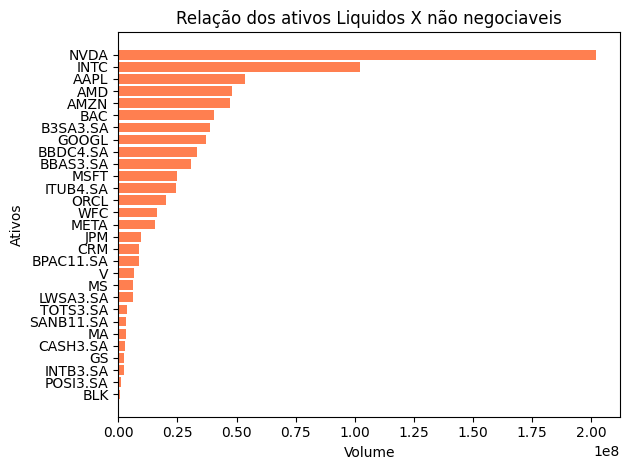

In [28]:
#Análise gráfica
volume_sorted = volume[['ticker','volume_medio_diario']].sort_values('volume_medio_diario',ascending=True)

plt.barh(volume_sorted['ticker'],volume_sorted['volume_medio_diario'], color='coral')
plt.title('Relação dos ativos Liquidos X não negociaveis')
plt.xlabel('Volume')
plt.ylabel('Ativos')

plt.tight_layout()
plt.savefig('Ativos_Liquidos_não_negociaveis.png')


## Correlação dos ativos

In [29]:
#Visualizar correlação
corr

,AAPL,AMD,AMZN,B3SA3.SA,BAC,BBAS3.SA,BBDC4.SA,BLK,BPAC11.SA,CASH3.SA,...,META,MS,MSFT,NVDA,ORCL,POSI3.SA,SANB11.SA,TOTS3.SA,V,WFC
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000,0.410,0.532,0.154,0.547,0.046,0.175,0.527,0.111,0.079,...,0.461,0.583,0.386,0.487,0.143,0.156,0.189,0.015,0.509,0.497
AMD,0.410,1.000,0.438,0.256,0.334,0.086,0.201,0.441,0.206,0.232,...,0.426,0.525,0.408,0.636,0.340,0.179,0.216,0.166,0.268,0.333
AMZN,0.532,0.438,1.000,0.160,0.479,0.145,0.203,0.459,0.118,0.146,...,0.619,0.538,0.501,0.540,0.246,0.135,0.213,0.074,0.381,0.463
B3SA3.SA,0.154,0.256,0.160,1.000,0.187,0.408,0.648,0.225,0.586,0.153,...,0.160,0.249,0.169,0.291,0.090,0.410,0.573,0.358,0.160,0.160
BAC,0.547,0.334,0.479,0.187,1.000,0.064,0.127,0.668,0.251,0.099,...,0.462,0.813,0.344,0.447,0.217,0.144,0.202,0.035,0.500,0.867
BBAS3.SA,0.046,0.086,0.145,0.408,0.064,1.000,0.375,0.081,0.425,0.031,...,0.101,0.080,0.080,0.136,0.125,0.265,0.491,0.219,0.061,0.038
BBDC4.SA,0.175,0.201,0.203,0.648,0.127,0.375,1.000,0.204,0.624,0.175,...,0.193,0.216,0.195,0.154,0.045,0.446,0.624,0.363,0.206,0.117
BLK,0.527,0.441,0.459,0.225,0.668,0.081,0.204,1.000,0.267,0.121,...,0.491,0.770,0.389,0.460,0.247,0.130,0.248,0.130,0.512,0.683
BPAC11.SA,0.111,0.206,0.118,0.586,0.251,0.425,0.624,0.267,1.000,0.188,...,0.143,0.295,0.145,0.157,0.054,0.444,0.556,0.423,0.180,0.211


In [30]:
correlacao_ativos = corr.mean().sort_values(ascending=False).reset_index()
correlacao_ativos.columns = ['Ativos','Média']
correlacao_ativos

,Ativos,Média
0,MS,0.452862
1,GS,0.450586
2,JPM,0.415034
3,BLK,0.397138
4,BAC,0.388276
5,WFC,0.371966
6,NVDA,0.369931
7,AMZN,0.359517
8,AAPL,0.350379
9,META,0.347310


In [31]:
#Correlação do B3 X NYSE
b3_tickers = df[df['mercado'] == 'B3']['ticker'].tolist()
eua_tickers = df[df['mercado'] == 'NYSE/NASDAQ']['ticker'].tolist()

corr_b3_eua = corr.loc[b3_tickers,eua_tickers]
print(f"Correlação média B3 x NYSE: {corr_b3_eua.mean().mean():.3f}")

Correlação média B3 x NYSE: 0.148


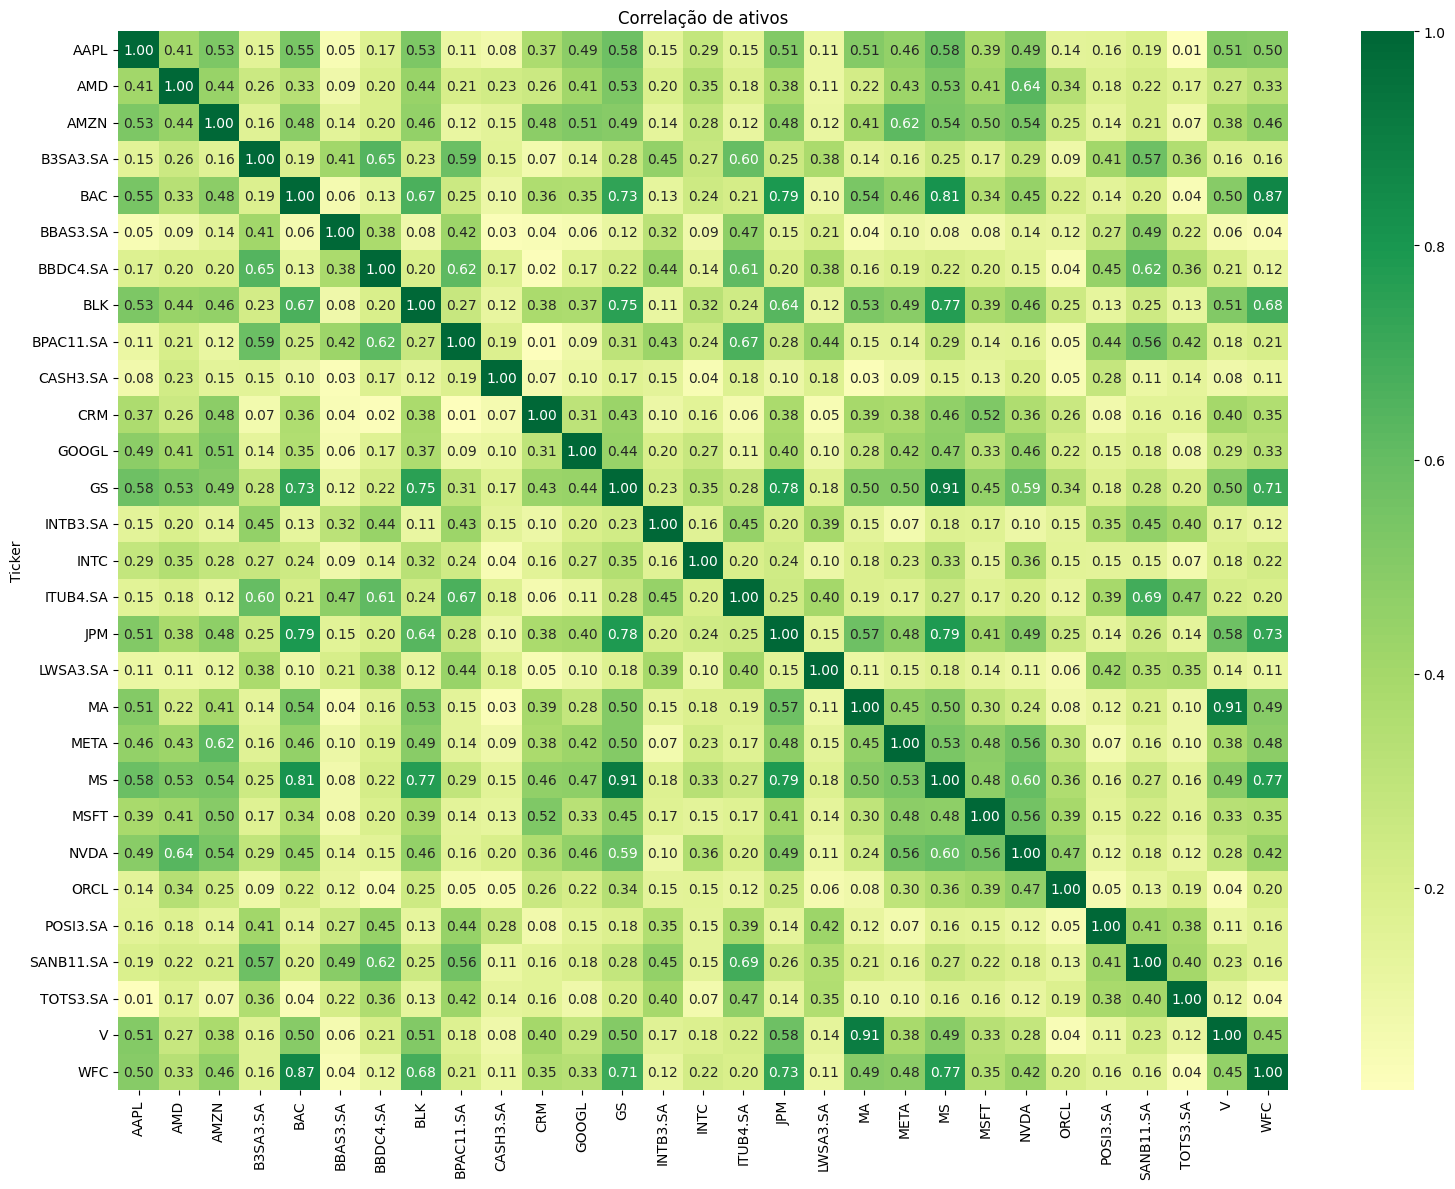

In [32]:
#Analise grafica
plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',center=0)
plt.title('Correlação de ativos')

plt.tight_layout()
plt.savefig('Correlacao.png')
